# HFEA (UPRO/TMF 55/45) — a quantitative teardown 🔬
### Per-leg synthesis calibrated & validated on the real funds · HAC log-gap races vs SPY and 60/40 · a mechanism-based regime split with a Welch difference test · the 2022 correlation autopsy · cost sweep · a planted/removed diversification-engine control

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![2022 falsified it?: Mixed](https://img.shields.io/badge/2022_falsified_it%3F-Mixed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim (Bogleheads, 2019): **55% UPRO / 45% TMF, quarterly rebalanced, compounds faster than SPY thanks to leveraged diversification.** Distinct from the desk's single-LETF decay studies ([61](../../61-slow-burn/README.md), [100](../../100-melting-ice/README.md)) — this is the *portfolio allocation* claim.

> ⚠️ **Data note.** yfinance daily total-return closes (SPY, TLT, UPRO, TMF) + ^IRX as the bill/financing leg; real funds from mid-2009, per-leg daily-leverage synthesis before (calibrated on the overlap, validated at corr 0.998/0.997). Window 2002-07 → 2026-06-30, gross unless labeled net; Sharpe races excess-vs-excess. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprint `b276ef14f488`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from hfea_leveraged_6040 import data as d, strategy as st

HAVE_REAL = d.have_real()
if HAVE_REAL:
    PX = d.load_real()
    TAPE = d.build_tape(PX, asof=d.AS_OF)
    CAL_S = d.calibrate_fee(TAPE["spy"], TAPE["rf"], TAPE["upro"])
    CAL_B = d.calibrate_fee(TAPE["tlt"], TAPE["rf"], TAPE["tmf"])
    LEGS = d.spliced_legs(TAPE, CAL_S["fee_ann"], CAL_B["fee_ann"])
    HFEA = st.rebalanced(LEGS["s3x"], LEGS["b3x"], st.HFEA_W)["ret"]
    SIXTY = st.rebalanced(LEGS["spy"], LEGS["tlt"], st.SIXTY_FORTY_W)["ret"]
    RF = LEGS["rf"]
else:
    PX = TAPE = LEGS = HFEA = SIXTY = RF = None
print("real HFEA cache present:", HAVE_REAL,
      "| days:", (0 if LEGS is None else len(LEGS)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2002-07-31', 'end': '2026-06-30', 'years': 23.9, 'n_months': 288, 'asof': '2026-06-30', 'fingerprint': 'b276ef14f488', 'cal': [('UPRO (3x SPY)', 2.13, 0.9983, 3.01, 1.0002), ('TMF (3x TLT)', 2.19, 0.9967, 3.64, 0.9998)], 'n_synth_days': 1739, 'n_real_days': 4278, 'n_resets': 96, 'reset_turnover_pct': 13.5, 'perf': [('HFEA 55/45', 17.47, 29.6, -70.8, 0.64, 46.8), ('SPY', 11.24, 18.8, -55.2, 0.68, 12.7), ('60/40 SPY/TLT', 8.99, 10.7, -30.1, 0.75, 7.8), ('UPRO leg (3x SPY)', 16.98, 56.4, -95.6, 0.55, None), ('TMF leg (3x TLT)', -0.39, 42.6, -92.7, 0.15, None)], 'race_spy': (5.42, 1.31), 'race_6040': (7.45, 1.91), 'reg_pre': ('2002-08..2021-12', 11.22, 2.98), 'reg_post': ('2022-01..2026-06', -19.71, -1.59), 'welch_regime': 2.23, 'reg_pre_6040': (11.97, 3.39), 'pre_cagr': (24.28, 0.92, 11.03, 0.72), 'post_cagr': (-8.02, -0.09, 12.18, 0.55), 'y2022': [('UPRO leg', -56.8), ('TMF leg', -72.6), ('HFEA 55/45', -64.2), ('SPY', -18.2), ('60/40', -23.5), ('TLT (1x)', -31.2)], 'corr': {'pre': -0.3, 'y2022': 0.51, 'recent': 0.32, 'full': -0.1}, 'dd': {'peak': '2021-12-27', 'trough': '2023-10-27', 'depth': -70.8, 'now': -32.2}, 'y2008': (-27.0, -36.8), 'y2020': (66.5, 18.3), 'costs': [(2.0, 17.46, 5.41, 1.31, 1.1), (5.0, 17.44, 5.4, 1.3, 2.7), (10.0, 17.41, 5.37, 1.3, 5.4)], 'fee3': (17.19, 5.18, 1.25), 'real_only': (23.07, 0.81, 15.16, 0.96, 6.61, 1.25), 'syn': [('PLANTED', -0.6, 6, 10.36, 4.9, 0.88, 100), ('NULL', 0.6, 0, -3.09, -0.83, 1.03, 0)]}


real HFEA cache present: True | days: 6017


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `MIXED` | Full-period log-CAGR gap vs SPY **+5.42%/yr** at **HAC t = 1.31** (below the bar); pre-2022 **+11.22%/yr at t = 2.98**, post-flip **-19.71%/yr**; regime difference **Welch t = 2.23**. Real on the ρ<0 regime, reversed since. |
| **Tradability** | `FRAGILE` | Costs ≤ 5 bps/yr (not the problem); maxDD **-70.8%**, still -32% under water, Sharpe **0.64 < 0.68** (SPY), insurance leg regime-dependent. |
| **2022 falsified it?** | `MIXED` | Corr -0.30 → +0.51; both legs -57%/-73% in 2022; yet full-tape wealth ×46.8 vs SPY ×12.7. A regime exposed, not a law dented. |

> 💡 In plain words: the engine is real machinery, the full-period edge is statistically uncertifiable, and the load-bearing assumption is a regime that broke in 2022.

## 1 · The claim, steelmanned

Let $r^{s3}_t, r^{b3}_t$ be daily returns of the 3x legs and $w = (0.55, 0.45)$. The portfolio drifts between quarter-ends and resets at each quarter's last close (earning from $t{+}1$ — the one documented lag):

$$r^{P}_t = w^{s}_t r^{s3}_t + w^{b}_t r^{b3}_t, \qquad w_{t^+} = (0.55, 0.45)\ \text{at quarter ends.}$$

- **H₁ (compounds faster).** $\mathbb{E}[\log(1+r^P_m) - \log(1+r^{SPY}_m)] > 0$, HAC t ≥ 2 (a geometric claim races in logs).
- **H₂ (the engine is diversification).** The edge requires ρ(stocks, bonds) < 0 plus bond carry — remove either and the pair should lose to the index (tested in the synthetic control *and* on the 2022 regime).
- **H₃ (survivable).** The drawdown/Sharpe profile beats the naked 3x fund and doesn't surrender the risk-adjusted race to plain SPY.

We find **H₁ uncertified** on the full tape (t = 1.31) and regime-split (pre-2022 t = 2.98, post-flip negative), **H₂ confirmed** in both directions, **H₃ half-true** (beats the naked leg; loses the Sharpe race to SPY).

## 2 · So what? — what rides on each answer

The inference design has three honesty problems to kill. **(a) Geometric vs arithmetic:** "compounds faster" is about log growth, so the race statistic is the mean monthly **log**-return gap with Newey-West errors (monthly returns of a 30%-vol levered pair are serially dependent through vol clustering). **(b) The pre-launch tape:** UPRO/TMF only exist since 2009 — the 2002–09 extension must be *validated*, not assumed; we calibrate the all-in fee on the overlap (terminal-NAV match) and require daily corr > 0.99, study-100's bar. **(c) The regime split must not be snooped:** we split at 2022-01 because that is the claim's own mechanism failing (the corr flip — an ex-ante, macro-dated marker), and we test the *difference* with a Welch t, per the desk's inference bar.

## 3 · How we'd know — the protocol

- **Tape.** 2002-07-31 → 2026-06-30 (23.9y, 288 months): real funds 4,278 days, synthesis 1,739 days (pre-launch).
- **Rule.** 55/45, reset at each quarter-end close (96 resets, avg 13.5% NAV traded); new weights earn from the next session.
- **Races.** vs SPY and vs 60/40 SPY/TLT (same machinery); HAC t on the monthly log gap; excess-vs-excess Sharpe (monthly, minus compounded ^IRX).
- **Costs.** One-way 2/5/10 bps × NAV traded per reset; fund ER + financing already inside the NAVs (and inside the calibrated synthesis fee).
- **Autopsy.** 2022 per-leg damage, the corr flip (monthly SPY/TLT corr by era), drawdown state at the as-of.
- **Control.** Two-asset seeded worlds, 3x legs, 55/45 quarterly: diversification engine PLANTED (ρ = −0.6, +6% bond carry) vs REMOVED (ρ = +0.6, zero carry), ≥ 20 seeds averaged.

## 4 · The teardown

### 4a · Synthesis calibration & validation (the pre-launch tape has to earn its place)

Daily identity $r^{3x}_t = 3 r^{idx}_t - 2 r^{bill}_t - f/252$; $f$ calibrated so the synthetic terminal NAV matches the real fund's over the overlap, then judged on daily correlation and tracking error.

UPRO (3x SPY): fee 2.13%/yr  corr 0.9983  TE 3.01%/yr  NAV ratio 1.0002  (4,278 d)
TMF (3x TLT): fee 2.19%/yr  corr 0.9967  TE 3.64%/yr  NAV ratio 0.9998  (4,327 d)


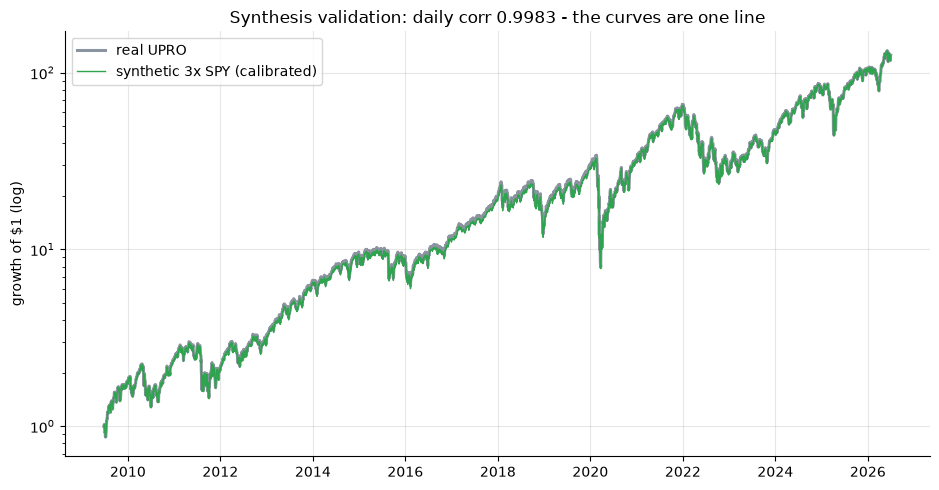

In [2]:
if HAVE_REAL:
    rows = [('UPRO (3x SPY)', CAL_S), ('TMF (3x TLT)', CAL_B)]
    for nm, c in rows:
        print(f"{nm}: fee {c['fee_ann']*100:.2f}%/yr  corr {c['corr']:.4f}  "
              f"TE {c['te_ann']*100:.2f}%/yr  NAV ratio {c['nav_ratio']:.4f}  ({c['n_days']:,} d)")
    # visual: synthetic vs real UPRO NAV on the overlap
    ov = pd.concat({'idx': TAPE['spy'], 'rf': TAPE['rf'], 'real': TAPE['upro']}, axis=1).dropna()
    syn = d.synth_letf(ov['idx'], ov['rf'], CAL_S['fee_ann'])
    fig, ax = plt.subplots()
    ax.plot((1+ov['real']).cumprod(), color=GREY, lw=2.2, label='real UPRO')
    ax.plot((1+syn).cumprod(), color=GREEN, lw=1.0, label='synthetic 3x SPY (calibrated)')
    ax.set_yscale('log'); ax.set_ylabel('growth of $1 (log)'); ax.legend()
    ax.set_title(f"Synthesis validation: daily corr {CAL_S['corr']:.4f} - the curves are one line")
    plt.tight_layout(); plt.show()
else:
    for nm, fee, corr, te, nav in R['cal']:
        print(f'{nm}: fee {fee:.2f}%/yr  corr {corr:.4f}  TE {te:.2f}%  NAV ratio {nav:.4f}')

> 💡 In plain words: the reconstruction is the real fund to within rounding — corr **0.9983** (UPRO) / **0.9967** (TMF), all-in drag ≈ **2.1–2.2%/yr** (ER + swap spread + 2× bills). The 2002–09 extension is earned, not assumed — and a pessimistic 3%/yr fee barely moves the headline (gap +5.18%/yr, t = 1.25).

### 4b · The race — full-period performance and the HAC log-gap

The full table, then the claim's own statistic: the mean monthly log-return gap vs SPY and vs 60/40, with Newey-West errors.

HFEA 55/45   CAGR  +17.47%  vol  29.6%  maxDD  -70.8%  Sharpe  0.64
SPY          CAGR  +11.24%  vol  18.8%  maxDD  -55.2%  Sharpe  0.68
60/40        CAGR   +8.99%  vol  10.7%  maxDD  -30.1%  Sharpe  0.75
UPRO leg     CAGR  +16.98%  vol  56.4%  maxDD  -95.6%  Sharpe  0.55
TMF leg      CAGR   -0.39%  vol  42.6%  maxDD  -92.7%  Sharpe  0.15

vs SPY  : gap +5.42%/yr  HAC t = +1.31
vs 60/40: gap +7.45%/yr  HAC t = +1.91


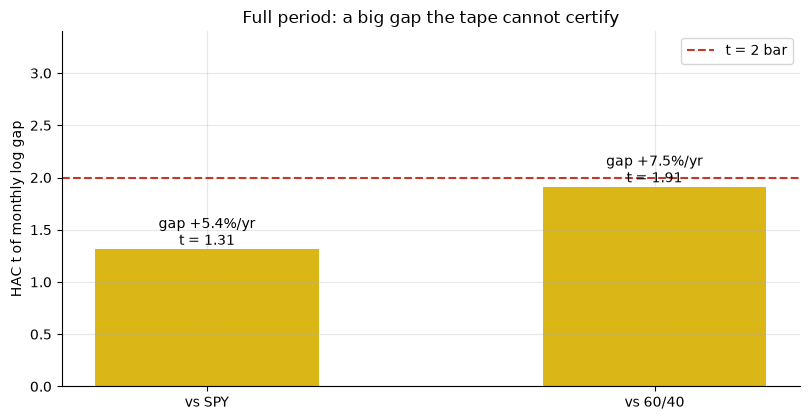

In [3]:
if HAVE_REAL:
    rows = [('HFEA 55/45', HFEA), ('SPY', LEGS['spy']), ('60/40', SIXTY),
            ('UPRO leg', LEGS['s3x']), ('TMF leg', LEGS['b3x'])]
    for nm, r in rows:
        p = st.perf(r, RF)
        print(f"{nm:12s} CAGR {p['cagr_pct']:+7.2f}%  vol {p['vol_ann_pct']:5.1f}%  "
              f"maxDD {p['max_dd_pct']:6.1f}%  Sharpe {p['sharpe']:5.2f}")
    r1, r2 = st.race(HFEA, LEGS['spy'], RF), st.race(HFEA, SIXTY, RF)
    print(f"\nvs SPY  : gap {r1['dlog_ann_pct']:+.2f}%/yr  HAC t = {r1['t_dlog_hac']:+.2f}")
    print(f"vs 60/40: gap {r2['dlog_ann_pct']:+.2f}%/yr  HAC t = {r2['t_dlog_hac']:+.2f}")
    gaps = [(r1['dlog_ann_pct'], r1['t_dlog_hac']), (r2['dlog_ann_pct'], r2['t_dlog_hac'])]
else:
    gaps = [R['race_spy'], R['race_6040']]
fig, ax = plt.subplots(figsize=(8.2, 4.3))
ax.bar(['vs SPY', 'vs 60/40'], [g[1] for g in gaps], color=AMBER, width=.5)
ax.axhline(2, ls='--', c=RED, label='t = 2 bar')
for i, g in enumerate(gaps): ax.annotate(f'gap {g[0]:+.1f}%/yr\nt = {g[1]:.2f}', (i, g[1]),
    ha='center', va='bottom')
ax.set_ylabel('HAC t of monthly log gap'); ax.set_ylim(0, 3.4)
ax.set_title('Full period: a big gap the tape cannot certify'); ax.legend()
plt.tight_layout(); plt.show()

> 💡 In plain words: **+5.4%/yr** of extra compounding sounds enormous — but a ~30%-vol strategy needs far more than 24 years to certify it: **HAC t = 1.31**, below the bar. And the Sharpe table is the quiet damnation: **0.64** (HFEA) < **0.68** (SPY) < **0.75** (60/40) — per unit of risk, the leverage bought *nothing*. Note also the allocation fact: the pair (+17.47%) beats both of its own legs (+16.98% / -0.39%) — the rebalancing engine itself is real.

### 4c · The regime split — the claim's own mechanism, tested

Split at 2022-01: the macro-dated stock-bond correlation flip (ex-ante marker, not return-snooped). Per the inference bar, the sub-period contrast carries a Welch t of the **difference**.

pre-2022 : +11.22%/yr  t=+2.98 (n=234)
post-flip: -19.71%/yr  t=-1.59 (n=54)
Welch t of the regime difference = +2.23


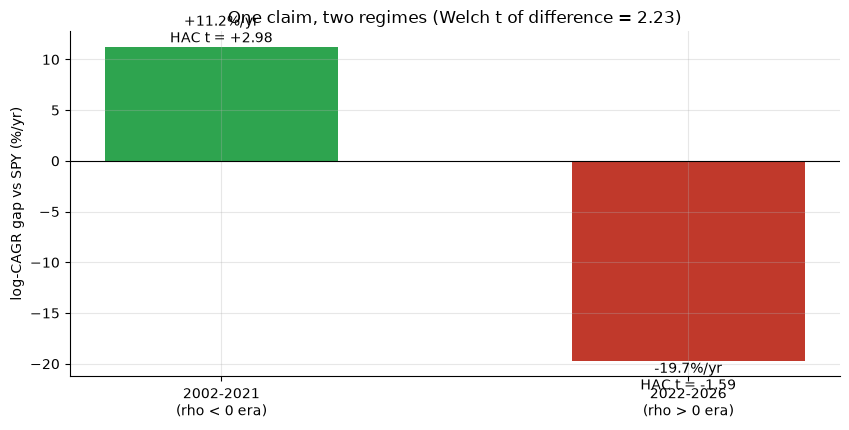

In [4]:
if HAVE_REAL:
    mp, mb = st.monthly(HFEA), st.monthly(LEGS['spy'])
    dlog = np.log1p(mp) - np.log1p(mb)
    pre = dlog[dlog.index <= pd.Period('2021-12','M')].to_numpy()
    post = dlog[dlog.index >= pd.Period('2022-01','M')].to_numpy()
    hp, hq = st.hac_mean_t(pre), st.hac_mean_t(post)
    wt = (pre.mean()-post.mean())/np.sqrt(pre.var(ddof=1)/len(pre)+post.var(ddof=1)/len(post))
    reg = [(hp['mean']*12*100, hp['t']), (hq['mean']*12*100, hq['t'])]
    print(f'pre-2022 : {reg[0][0]:+.2f}%/yr  t={reg[0][1]:+.2f} (n={len(pre)})')
    print(f'post-flip: {reg[1][0]:+.2f}%/yr  t={reg[1][1]:+.2f} (n={len(post)})')
    print(f'Welch t of the regime difference = {wt:+.2f}')
else:
    reg = [R['reg_pre'][1:], R['reg_post'][1:]]; wt = R['welch_regime']
fig, ax = plt.subplots(figsize=(8.6, 4.4))
ax.bar(['2002-2021\n(rho < 0 era)', '2022-2026\n(rho > 0 era)'], [reg[0][0], reg[1][0]],
       color=[GREEN, RED], width=.5)
for i, (g, t) in enumerate(reg): ax.annotate(f'{g:+.1f}%/yr\nHAC t = {t:+.2f}', (i, g),
    ha='center', va='bottom' if g > 0 else 'top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('log-CAGR gap vs SPY (%/yr)')
ax.set_title(f'One claim, two regimes (Welch t of difference = {wt:.2f})')
plt.tight_layout(); plt.show()

> 💡 In plain words: pre-2022 the claim was **real on the tape** — +11.2%/yr at HAC t = 2.98 vs SPY (and +12.0%/yr at t = 3.39 vs 60/40), with HFEA Sharpe 0.92 *above* SPY's 0.72. Since the flip it runs -19.7%/yr (HFEA CAGR -8.0%, Sharpe -0.09 vs SPY's 0.55), and the two eras are genuinely different (Welch t = 2.23). The signal is **regime-conditional** — hence `MIXED`, spelled out.

### 4d · The 2022 autopsy — the correlation flip in one chart

Rolling 24-month SPY/TLT correlation (monthly returns). The whole thesis lives below zero.

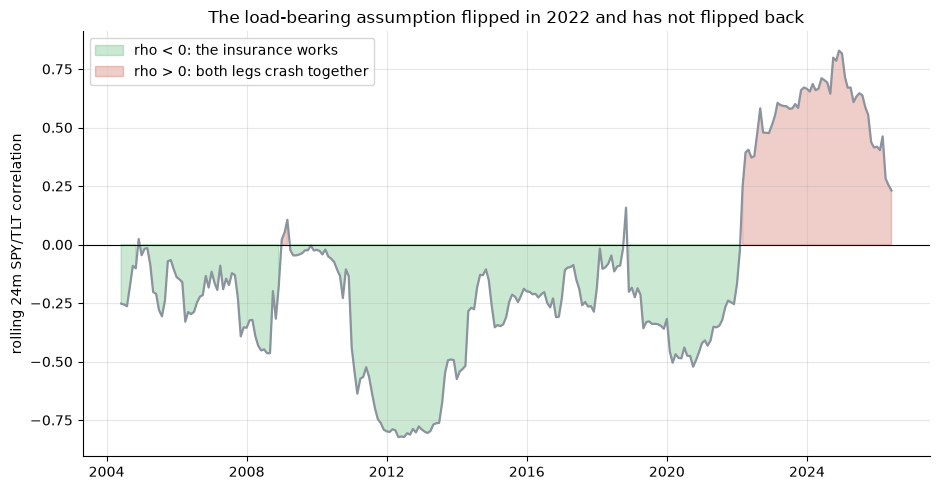

era correlations: {'2002-2021': -0.3, '2022': 0.51, '2024-2026': 0.32}
2022 damage: {'UPRO leg': -56.8, 'TMF leg': -72.6, 'HFEA': -64.2, 'SPY': -18.2}


In [5]:
if HAVE_REAL:
    rc = st.rolling_corr(LEGS, window=24).dropna()
    fig, ax = plt.subplots()
    ax.plot(rc.index.to_timestamp(), rc.values, color=GREY, lw=1.6)
    ax.fill_between(rc.index.to_timestamp(), rc.values, 0, where=(rc.values<0), color=GREEN, alpha=.25,
                    label='rho < 0: the insurance works')
    ax.fill_between(rc.index.to_timestamp(), rc.values, 0, where=(rc.values>=0), color=RED, alpha=.25,
                    label='rho > 0: both legs crash together')
    ax.axhline(0, c='k', lw=.8); ax.set_ylabel('rolling 24m SPY/TLT correlation')
    ax.set_title('The load-bearing assumption flipped in 2022 and has not flipped back')
    ax.legend(loc='upper left'); plt.tight_layout(); plt.show()
    print('era correlations:', {'2002-2021': round(st.stock_bond_corr(LEGS, end='2021-12'),2),
          '2022': round(st.stock_bond_corr(LEGS, start='2022-01', end='2022-12'),2),
          '2024-2026': round(st.stock_bond_corr(LEGS, start='2024-01'),2)})
    print('2022 damage:', {nm: round(st.year_return(r, 2022),1) for nm, r in
          [('UPRO leg', LEGS['s3x']), ('TMF leg', LEGS['b3x']), ('HFEA', HFEA), ('SPY', LEGS['spy'])]})
else:
    print('canonical:', R['corr'], R['y2022'])

> 💡 In plain words: monthly stock-bond correlation was **-0.30** for two decades — exactly the world HFEA was designed in — then hit **+0.51** in 2022 and still sits at **+0.32** in 2024–26. In that year the *insurance* leg lost -73% — more than the stock leg — and the pair gave back -64%. Contrast 2008 (HFEA -27% vs SPY -37%, the 3x bond leg +110%) and 2020 (+66%): same machine, opposite regime, opposite outcome.

### 4e · Costs & robustness — quarterly rebalancing is (almost) free

One-way costs × NAV traded per reset, plus the pessimistic-fee and real-funds-only checks.

In [6]:
if HAVE_REAL:
    for cb in (2.0, 5.0, 10.0):
        h = st.rebalanced(LEGS['s3x'], LEGS['b3x'], st.HFEA_W, cost_bps=cb)
        p = st.perf(h['ret'], RF); rr = st.race(h['ret'], LEGS['spy'], RF)
        print(f"{cb:4.1f} bps: net CAGR {p['cagr_pct']:+.2f}%  gap {rr['dlog_ann_pct']:+.2f}%/yr  "
              f"t = {rr['t_dlog_hac']:+.2f}  (drag {h['ann_cost_bps']:.1f} bps/yr)")
    real = LEGS[LEGS['src'] == 'real']
    hr = st.rebalanced(real['s3x'], real['b3x'], st.HFEA_W)['ret']
    rr = st.race(hr, real['spy'], real['rf'])
    pr, ps = st.perf(hr, real['rf']), st.perf(real['spy'], real['rf'])
    print(f"real-only 2009->: gap {rr['dlog_ann_pct']:+.2f}%/yr t = {rr['t_dlog_hac']:+.2f}  "
          f"Sharpe {pr['sharpe']:.2f} vs SPY {ps['sharpe']:.2f}")
else:
    for c in R['costs']: print(c)
    print('real-only:', R['real_only'])

 2.0 bps: net CAGR +17.46%  gap +5.41%/yr  t = +1.31  (drag 1.1 bps/yr)


 5.0 bps: net CAGR +17.44%  gap +5.40%/yr  t = +1.30  (drag 2.7 bps/yr)


10.0 bps: net CAGR +17.41%  gap +5.37%/yr  t = +1.30  (drag 5.4 bps/yr)


real-only 2009->: gap +6.61%/yr t = +1.25  Sharpe 0.81 vs SPY 0.96


> 💡 In plain words: even at 10 bps one-way the annual drag is ~5 bps — costs are a rounding error at quarterly cadence (the funds' internal ~2%/yr financing+ER drag is already inside the NAVs). Tradability fails on **risk**, not friction: −71% drawdown, 32% still unrecovered, and a real-funds-only Sharpe of 0.81 vs SPY's 0.96. Hence `FRAGILE`.

### 4f · Faithful-engine control — plant the engine, then remove it

Seeded two-asset worlds, 3x legs, 55/45 quarterly, race vs the 1x stock. PLANTED: ρ = −0.6 with +6% bond carry (the engine at full strength). NULL: ρ = +0.6, zero carry — the 2022 world made permanent. Averaged over seeds (canonical run: 20 seeds × 40y in `examples/verify.py`; this cell runs a lighter 8 × 25y for speed).

PLANTED  rho=-0.6 carry=6%: mean gap +10.85%/yr  mean t = +4.17  share t>=2: 100%


NULL     rho=+0.6 carry=0%: mean gap -2.51%/yr  mean t = -0.49  share t>=2: 0%
canonical (20 seeds x 40y): [('PLANTED', -0.6, 6, 10.36, 4.9, 0.88, 100), ('NULL', 0.6, 0, -3.09, -0.83, 1.03, 0)]


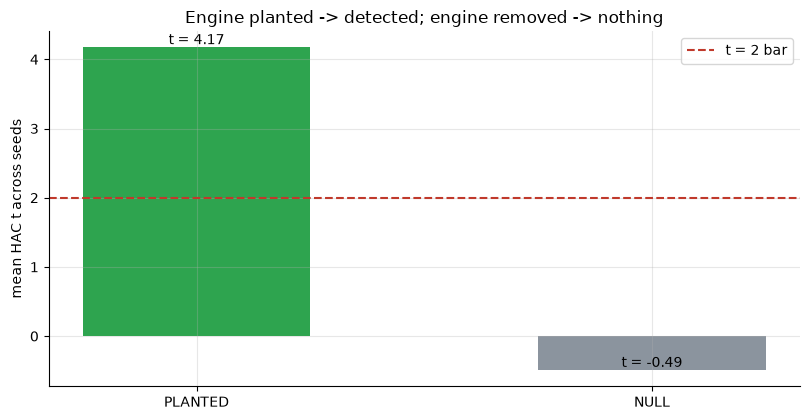

In [7]:
res = []
for nm, rho, carry in [('PLANTED', -0.6, 0.06), ('NULL', +0.6, 0.0)]:
    c = st.synthetic_check(rho=rho, bond_mu_exc=carry, n_seeds=8, n_years=25)
    res.append((nm, c))
    print(f"{nm:8s} rho={rho:+.1f} carry={carry*100:.0f}%: mean gap {c['mean_gap_ann_pct']:+.2f}%/yr  "
          f"mean t = {c['mean_t']:+.2f}  share t>=2: {c['share_t_ge_2']*100:.0f}%")
print('canonical (20 seeds x 40y):', R['syn'])
fig, ax = plt.subplots(figsize=(8.2, 4.3))
ax.bar([r[0] for r in res], [r[1]['mean_t'] for r in res], color=[GREEN, GREY], width=.5)
ax.axhline(2, ls='--', c=RED, label='t = 2 bar')
for i, r in enumerate(res): ax.annotate(f"t = {r[1]['mean_t']:.2f}", (i, r[1]['mean_t']),
    ha='center', va='bottom')
ax.set_ylabel('mean HAC t across seeds')
ax.set_title('Engine planted -> detected; engine removed -> nothing'); ax.legend()
plt.tight_layout(); plt.show()

> 💡 In plain words: with the diversification engine planted the harness banks it (canonical: mean t = +4.90, 100% of seeds ≥ 2); in the permanent-2022 world it refuses to invent one (mean t = -0.83, 0%). The machinery is faithful in both directions. *(A machinery proof only — never cited in support of the Signal stamp.)*

## 5 · The verdict

- **Signal `MIXED`** — full-period gap vs SPY **+5.42%/yr** at **HAC t = 1.31** (uncertifiable); split on the claim's own mechanism: **+11.22%/yr at t = 2.98** in the ρ<0 era, **-19.71%/yr** since the flip, regime difference **Welch t = 2.23**. Real on one regime, reversed on the other — never a full-tape certification.
- **Tradability `FRAGILE`** — liquid ETFs, ≤ 5 bps/yr rebalance drag, but **-70.8%** max drawdown, -32% below peak at the as-of, Sharpe 0.64 < SPY's 0.68 < 60/40's 0.75, and the insurance leg depends on a correlation regime that broke. Not INVESTABLE; not quite a Mirage (×46.8 vs ×12.7 raw wealth, disaster included).
- **2022 falsified it? `MIXED`** — the *law* ("bonds insure stocks") is falsified: corr -0.30 → +0.51 (still +0.32 in 2024–26), both legs down -57%/-73% together, risk-adjusted case gone. The *arithmetic* survives on the full tape. HFEA compounds faster when and only when its regime holds — a regime bet, not a law.

## 6 · Going further

- **The financing regime is the other hidden leg.** The 2010s gave ZIRP financing (the funds' borrow drag ≈ 2×bills + spread ≈ 2%/yr all-in at the calibrated fee); at 2023-era bill rates the same structure paid >10%/yr to hold. Any HFEA revival case must price that.
- **Rebalancing cadence is not the knob.** Monthly (+14.7% CAGR) and annual (+17.0%) rebalancing bracket the quarterly headline (+17.5%) — the verdict never moves; quarterly wasn't cherry-picked.
- **The regime question is the whole question.** [579 — equity-bond-corr-flip](../../579-equity-bond-corr-flip/README.md) tests the correlation regime directly; [61](../../61-slow-burn/README.md) / [100](../../100-melting-ice/README.md) cover the single-fund decay mechanics this study deliberately does not re-litigate.

*The reproducible core is offline and deterministic; canonical numbers live in [`docs/results.md`](../docs/results.md) and are reprinted by [`examples/verify.py`](../examples/verify.py).*